In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [3]:
f = pd.read_csv(
    "/content/sample_data/bank_marketing_feature_engineered.csv"
)

In [4]:
f.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,previously_contacted
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,No
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,No
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,Yes
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,No
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,Yes


In [5]:
f['y']=f['y'].map({
    'no':0,
    "yes":1
})

In [6]:
f['y'].value_counts()

,count
y,


In [7]:
f['y'].value_counts(normalize=True)*100

,proportion
y,


In [8]:
X= f.drop('y',axis=1)
y=f['y']

In [9]:
numeric_features = [
    'age',
    'campaign',
    'pdays',
    'previous',
    'emp_var_rate',
    'cons_price_idx',
    'cons_conf_idx',
    'euribor3m',
    'nr_employed'
]

In [10]:
categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome',
    'previously_contacted'
]

In [11]:
missing_features = [
    col for col in numeric_features + categorical_features
    if col not in X.columns
]

print("Missing features:", missing_features)

Missing features: []


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [13]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [27]:
class_distribution = y.value_counts()

print(class_distribution)

Series([], Name: count, dtype: int64)


In [28]:
print(
    y.value_counts(normalize=True) * 100
)

Series([], Name: proportion, dtype: float64)


In [15]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [30]:
import pandas as pd

# Re-load the data to get a fresh copy of the DataFrame `f`
# This is necessary because the previous `f['y'].map()` operation corrupted `f['y']` to all NaNs.
original_f = pd.read_csv("/content/sample_data/bank_marketing_feature_engineered.csv")

# Extract X and y correctly from the original data
# Assuming 'y' column in the CSV is already 0s and 1s based on f.head() output.
X_fixed = original_f.drop('y', axis=1)
y_fixed = original_f['y']

# Now fit the model with the corrected X and y
logistic_model.fit(X_fixed, y_fixed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'previously_contacted'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [31]:
y_pred_lr = logistic_model.predict(X)

In [32]:
y_prob_lr = logistic_model.predict_proba(X)[:, 1]

In [36]:
accuracy_lr = accuracy_score(y_fixed, y_pred_lr)
precision_lr = precision_score(y_fixed, y_pred_lr)
recall_lr = recall_score(y_fixed, y_pred_lr)
f1_lr = f1_score(y_fixed, y_pred_lr)
roc_auc_lr = roc_auc_score(y_fixed, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

Logistic Regression
-------------------
Accuracy : 0.82859085170438
Precision: 0.3536526366715046
Recall   : 0.6301724137931034
F1 Score : 0.4530523706228695
ROC-AUC  : 0.7965251943122507


In [38]:
print(
    classification_report(
        y_fixed,
        y_pred_lr,
        target_names=[
            'No Subscription',
            'Subscription'
        ]
    )
)

                 precision    recall  f1-score   support

No Subscription       0.95      0.85      0.90     36548
   Subscription       0.35      0.63      0.45      4640

       accuracy                           0.83     41188
      macro avg       0.65      0.74      0.68     41188
   weighted avg       0.88      0.83      0.85     41188



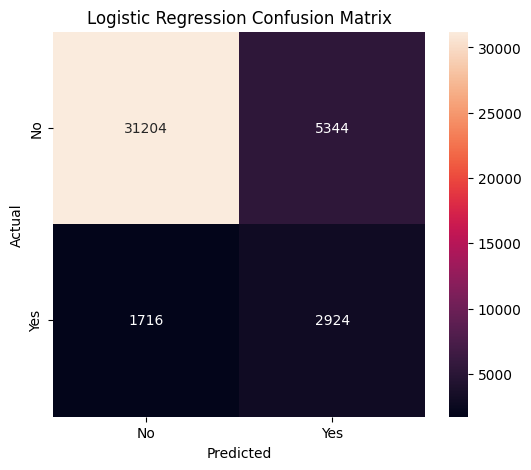

In [41]:
cm_lr = confusion_matrix(y_fixed, y_pred_lr)

plt.figure(figsize=(6, 5))

sn.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [16]:
class_weight='balanced'

In [17]:
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=6,
            min_samples_split=20,
            random_state=42
        ))
    ]
)

In [43]:
decision_tree_model.fit(X_fixed, y_fixed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'previously_contacted'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_split=20,
                                        random_state=42))])

In [44]:
y_pred_dt= decision_tree_model.predict(X)

In [45]:
y_prob_dt= decision_tree_model.predict_proba(X)[:1]

In [48]:
y_prob_dt = decision_tree_model.predict_proba(X)[:, 1]

accuracy_dt = accuracy_score(y_fixed, y_pred_dt)
precision_dt = precision_score(y_fixed, y_pred_dt)
recall_dt = recall_score(y_fixed, y_pred_dt)
f1_dt = f1_score(y_fixed, y_pred_dt)
roc_auc_dt = roc_auc_score(y_fixed, y_prob_dt)

print("Decision Tree")
print("-------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

Decision Tree
-------------
Accuracy : 0.8048946295037389
Precision: 0.323125
Recall   : 0.6685344827586207
F1 Score : 0.4356741573033708
ROC-AUC  : 0.7975402004402333


In [49]:
print(
    classification_report(
        y_fixed,
        y_pred_dt,
        target_names=[
            'No Subscription',
            'Subscription'
        ]
    )
)

                 precision    recall  f1-score   support

No Subscription       0.95      0.82      0.88     36548
   Subscription       0.32      0.67      0.44      4640

       accuracy                           0.80     41188
      macro avg       0.64      0.75      0.66     41188
   weighted avg       0.88      0.80      0.83     41188



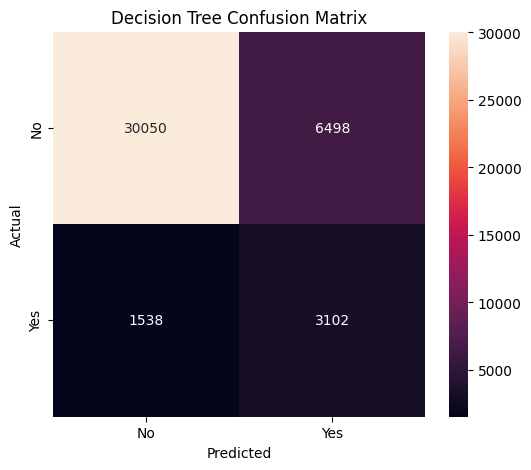

In [51]:
cm_dt = confusion_matrix(y_fixed, y_pred_dt)

plt.figure(figsize=(6, 5))

sn.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [18]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [52]:
random_forest_model.fit(X_fixed, y_fixed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'previously_contacted'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [53]:
y_pred_rf = random_forest_model.predict(X)

In [54]:
y_prob_rf = random_forest_model.predict_proba(X)[:, 1]

In [56]:
accuracy_rf = accuracy_score(y_fixed, y_pred_rf)
precision_rf = precision_score(y_fixed, y_pred_rf)
recall_rf = recall_score(y_fixed, y_pred_rf)
f1_rf = f1_score(y_fixed, y_pred_rf)
roc_auc_rf = roc_auc_score(y_fixed, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Random Forest
-------------
Accuracy : 0.8597164222589103
Precision: 0.4184112417550903
Recall   : 0.6288793103448276
F1 Score : 0.5024969863957293
ROC-AUC  : 0.8457264838068406


In [57]:
print(
    classification_report(
        y_fixed,
        y_pred_rf,
        target_names=[
            'No Subscription',
            'Subscription'
        ]
    )
)

                 precision    recall  f1-score   support

No Subscription       0.95      0.89      0.92     36548
   Subscription       0.42      0.63      0.50      4640

       accuracy                           0.86     41188
      macro avg       0.68      0.76      0.71     41188
   weighted avg       0.89      0.86      0.87     41188



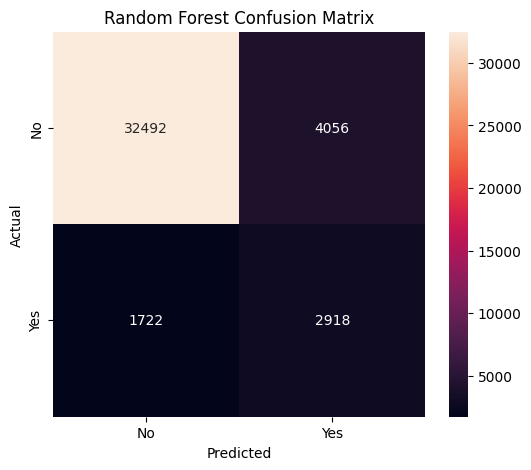

In [59]:
cm_rf = confusion_matrix(y_fixed, y_pred_rf)

plt.figure(figsize=(6, 5))

sn.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [60]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    'F1 Score': [
        f1_lr,
        f1_dt,
        f1_rf
    ],

    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8286,0.3537,0.6302,0.4531,0.7965
1,Decision Tree,0.8049,0.3231,0.6685,0.4357,0.7975
2,Random Forest,0.8597,0.4184,0.6289,0.5025,0.8457


In [62]:
import os

# Create the directory if it does not exist
os.makedirs("../data", exist_ok=True)

results.to_csv(
    "../data/model_comparison.csv",
    index=False
)

In [63]:
fpr_lr, tpr_lr, _ = roc_curve(y_fixed, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_fixed, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_fixed, y_prob_rf)

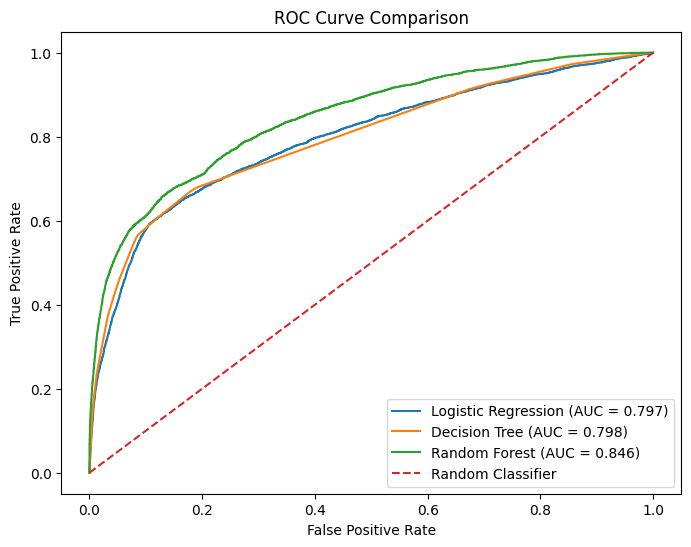

In [64]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

In [65]:
rf_classifier = random_forest_model.named_steps['classifier']

rf_preprocessor = random_forest_model.named_steps['preprocessor']

In [66]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [67]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
})

In [68]:
feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

In [69]:
feature_importance.head(20)

,Feature,Importance
8,num__nr_employed,0.171356
7,num__euribor3m,0.171038
4,num__emp_var_rate,0.122560
6,num__cons_conf_idx,0.066334
5,num__cons_price_idx,0.043930
2,num__pdays,0.037911
62,cat__previously_contacted_No,0.036293
63,cat__previously_contacted_Yes,0.036185
0,num__age,0.027745
50,cat__month_may,0.025825


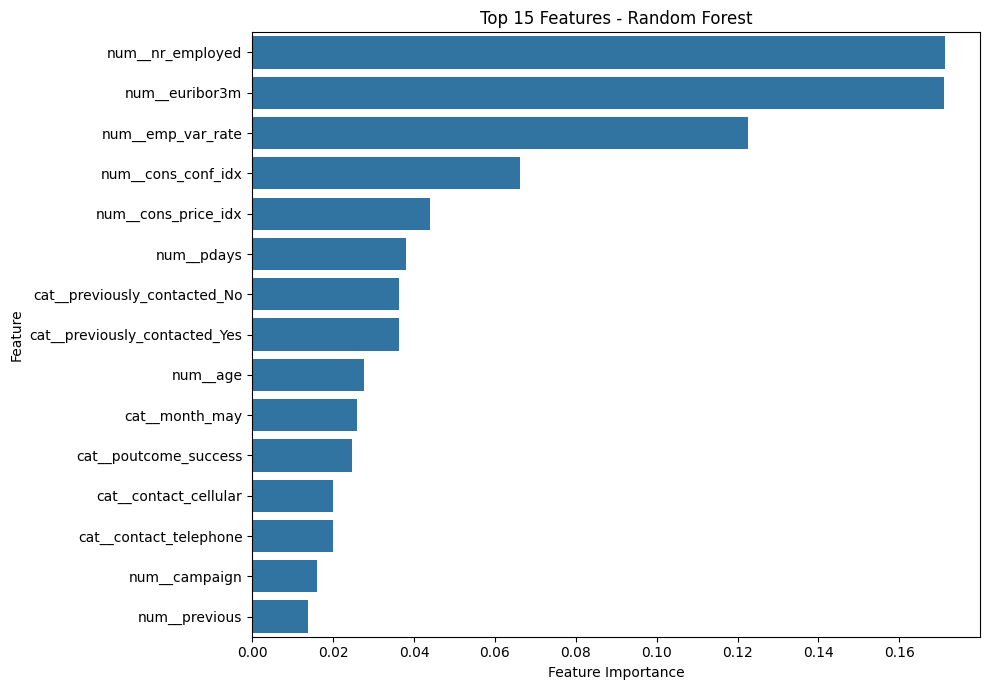

In [70]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sn.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features - Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [71]:
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [72]:
prediction_df = X.copy()

prediction_df['actual'] = y_fixed

prediction_df['predicted'] = y_pred_rf

prediction_df['subscription_probability'] = y_prob_rf

In [73]:
prediction_df['response_category'] = pd.cut(
    prediction_df['subscription_probability'],
    bins=[0, 0.30, 0.60, 1.00],
    labels=[
        'Low Probability',
        'Medium Probability',
        'High Probability'
    ],
    include_lowest=True
)

In [74]:
prediction_df['response_category'].value_counts()

,count
response_category,
Low Probability,19493
Medium Probability,15682
High Probability,6013


In [75]:
prediction_df.to_csv(
    "../data/ml_predictions.csv",
    index=False
)

In [76]:
from google.colab import files

files.download(
    "../data/ml_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>